<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/analisis_objetivo_4tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Detallado del Objetivo Específico 4: Comparación de Modelos Tradicionales y Supervisados

Este notebook presenta un análisis exhaustivo del Objetivo Específico 4 de la tesis "Uso de modelos supervisados por analistas financieros en la predicción de precios de acciones de Google y Amazon". El objetivo se centra en "Evaluar la precisión de los modelos supervisados seleccionados (Random Forest y Gradient Boosting) en comparación con modelos tradicionales (ARIMA y GARCH) para la predicción de precios de acciones financieras".

Se explorará el dataset proporcionado, se implementarán y compararán modelos tradicionales de series de tiempo (ARIMA, GARCH) con modelos de Machine Learning supervisados (Random Forest, Gradient Boosting), y se analizarán sus rendimientos y las implicaciones financieras.

## Fase 1: Análisis del Documento PDF y Contexto del Objetivo Específico 4

El Objetivo Específico 4 busca comparar la precisión de los modelos supervisados (Random Forest y Gradient Boosting) con modelos tradicionales (ARIMA y GARCH) en la predicción de precios de acciones financieras. Esto implica una evaluación rigurosa de las métricas de rendimiento para determinar la superioridad de un enfoque sobre otro.

**Objetivo Específico 4:** "Evaluar la precisión de los modelos supervisados seleccionados (Random Forest y Gradient Boosting) en comparación con modelos tradicionales (ARIMA y GARCH) para la predicción de precios de acciones financieras."

## Fase 2: Preparación del Dataset para el Objetivo 4

Cargamos el dataset `dataset_completo_google_amazon.csv` y realizamos la preparación necesaria, incluyendo la creación de características de `lag` y la división de los datos en conjuntos de entrenamiento y prueba para asegurar una evaluación justa de los modelos.

In [3]:
!pip install pmdarima
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 15.5 MB/s eta 0:00:00


Librerías importadas correctamente.
Análisis para: GOOGL

Dataset limpio con 992 registros.
Periodo de entrenamiento: 2021-01-11 a 2024-03-13
Periodo de prueba: 2024-03-14 a 2024-12-30

--- Iniciando Búsqueda Manual de Parámetros para ARIMA ---
Evaluando combinaciones (p, d, q)...
  > Mejor configuración encontrada: ARIMA(0, 0, 0) con AIC=6787.477
  > Mejor configuración encontrada: ARIMA(0, 0, 1) con AIC=5840.542
  > Mejor configuración encontrada: ARIMA(0, 0, 2) con AIC=5174.372
  > Mejor configuración encontrada: ARIMA(0, 0, 3) con AIC=4769.109
  > Mejor configuración encontrada: ARIMA(0, 0, 4) con AIC=4491.458
  > Mejor configuración encontrada: ARIMA(0, 0, 5) con AIC=4323.554
  > Mejor configuración encontrada: ARIMA(0, 1, 0) con AIC=3585.127
  > Mejor configuración encontrada: ARIMA(1, 1, 1) con AIC=3585.018

Búsqueda finalizada. Mejor modelo: ARIMA(1, 1, 1) con AIC=3585.018

--- Entrenando Modelo ARIMA Final con orden (1, 1, 1) ---

Resumen del Modelo ARIMA Ajustado:
           

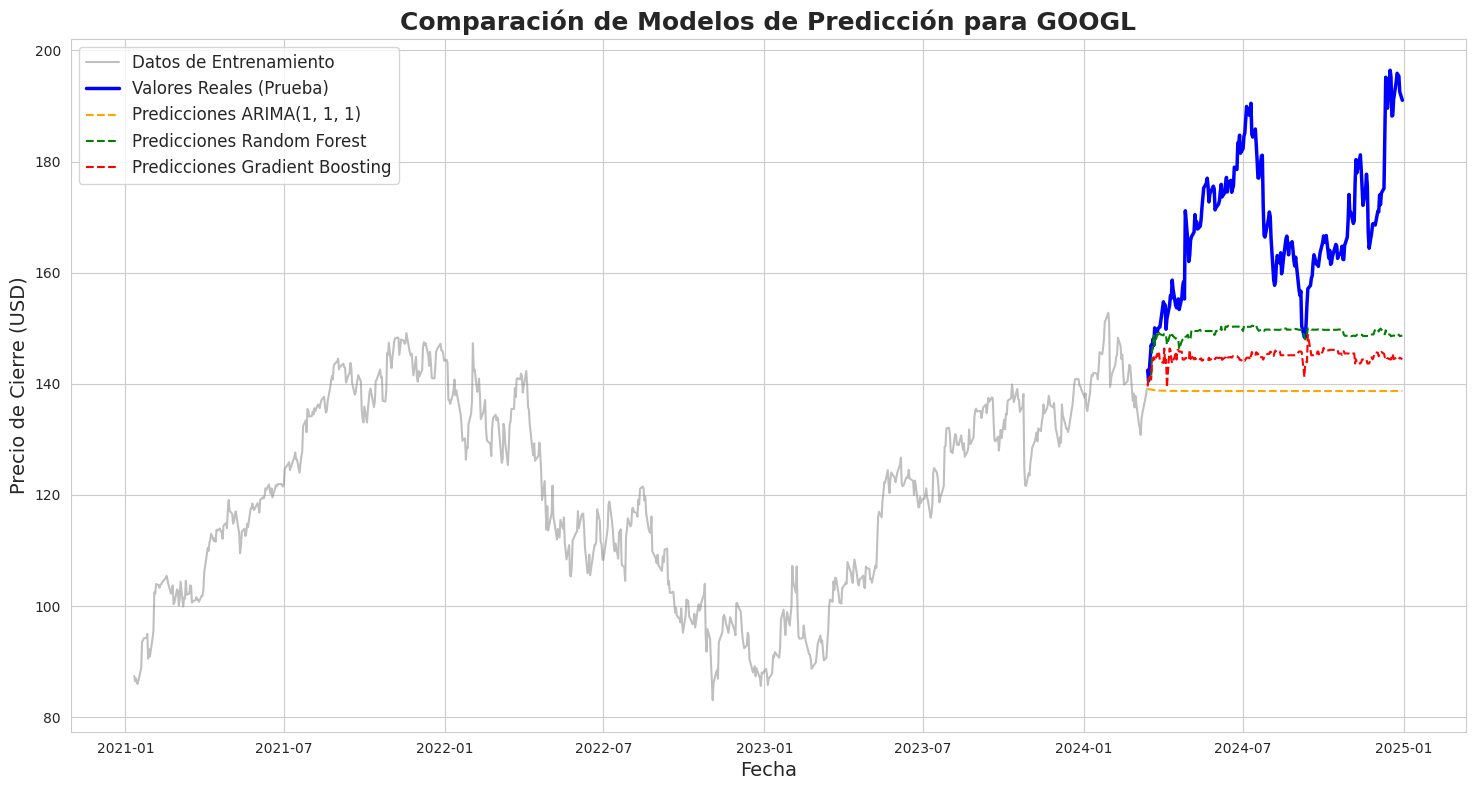

In [5]:
# =============================================================================
# FASE 1: CONFIGURACIÓN DEL ENTORNO
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings # Para manejar las advertencias de los modelos

# Suprimir advertencias que pueden surgir durante la búsqueda de ARIMA
warnings.filterwarnings("ignore")

# Configuración visual para los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)
print("Librerías importadas correctamente.")


# =============================================================================
# FASE 2: CARGA Y PREPARACIÓN DE DATOS
# =============================================================================
# Cargar el dataset desde el archivo CSV
try:
    df = pd.read_csv('dataset_completo_google_amazon.csv')
except FileNotFoundError:
    print("Error: El archivo 'dataset_completo_google_amazon.csv' no fue encontrado.")
    exit()

# Preparación de la columna de fecha
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Seleccionar el activo a analizar
STOCK_TICKER = 'GOOGL'
TARGET_COLUMN = f'{STOCK_TICKER}_Close'

print(f"Análisis para: {STOCK_TICKER}")


# =============================================================================
# FASE 3: INGENIERÍA DE CARACTERÍSTICAS
# =============================================================================
# Crear variables rezagadas (lags)
for i in range(1, 6):
    df[f'{STOCK_TICKER}_Lag_{i}'] = df[TARGET_COLUMN].shift(i)

df_clean = df.dropna()
print(f"\nDataset limpio con {len(df_clean)} registros.")


# =============================================================================
# FASE 4: DIVISIÓN DE DATOS (TRAIN/TEST SPLIT)
# =============================================================================
# Características para modelos supervisados
features = [col for col in df_clean.columns if STOCK_TICKER in col and 'Lag' in col]
features.extend(['Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE'])

X = df_clean[features]
y = df_clean[TARGET_COLUMN]

# División cronológica
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Periodo de entrenamiento: {y_train.index.min().date()} a {y_train.index.max().date()}")
print(f"Periodo de prueba: {y_test.index.min().date()} a {y_test.index.max().date()}")


# =============================================================================
# FASE 5: DEFINICIÓN DE FUNCIONES DE APOYO
# =============================================================================
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mse)

    metrics = {
        'Modelo': model_name,
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse,
        'R^2': r2
    }
    return metrics

results_list = []


# =============================================================================
# FASE 6.1: MODELO 1 (LÍNEA BASE) - BÚSQUEDA MANUAL DE ARIMA
# =============================================================================
print("\n--- Iniciando Búsqueda Manual de Parámetros para ARIMA ---")

# Función para encontrar el mejor orden ARIMA
def find_best_arima(data, p_values, d_values, q_values):
    best_score, best_cfg = float("inf"), None
    print("Evaluando combinaciones (p, d, q)...")
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)
                try:
                    # Ajustar el modelo ARIMA
                    model = ARIMA(data, order=order)
                    model_fit = model.fit()
                    # Si el AIC es mejor (más bajo), se guarda la configuración
                    if model_fit.aic < best_score:
                        best_score, best_cfg = model_fit.aic, order
                        print(f'  > Mejor configuración encontrada: ARIMA{order} con AIC={best_score:.3f}')
                except:
                    # Algunas combinaciones pueden fallar, las ignoramos
                    continue
    print(f'\nBúsqueda finalizada. Mejor modelo: ARIMA{best_cfg} con AIC={best_score:.3f}')
    return best_cfg

# Definir los rangos para p, d, q
# (Se usan rangos pequeños para que la búsqueda sea rápida)
p_range = range(0, 6) # Componente Autorregresivo
d_range = range(0, 3) # Grado de Diferenciación
q_range = range(0, 6) # Componente de Media Móvil

# Ejecutar la búsqueda
best_order = find_best_arima(y_train, p_range, d_range, q_range)

# Entrenar el modelo ARIMA final con la mejor configuración encontrada
print(f"\n--- Entrenando Modelo ARIMA Final con orden {best_order} ---")
final_arima_model = ARIMA(y_train, order=best_order)
final_arima_fit = final_arima_model.fit()

# Imprimir el resumen del modelo, que incluye AIC, BIC, etc.
print("\nResumen del Modelo ARIMA Ajustado:")
print(final_arima_fit.summary())

# Realizar predicciones en el conjunto de prueba
arima_predictions = final_arima_fit.forecast(steps=len(y_test))
arima_predictions.index = y_test.index

# Evaluar el modelo ARIMA
arima_metrics = evaluate_model(y_test, arima_predictions, 'ARIMA')
results_list.append(arima_metrics)
print("\nMétricas de Rendimiento para ARIMA en el conjunto de prueba:")
print(pd.DataFrame([arima_metrics]))


# =============================================================================
# FASE 6.2 y 6.3: MODELOS SUPERVISADOS (SIN CAMBIOS)
# =============================================================================
# Random Forest
print("\n--- Entrenando Modelo Random Forest ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_metrics = evaluate_model(y_test, rf_predictions, 'Random Forest')
results_list.append(rf_metrics)

# Gradient Boosting
print("\n--- Entrenando Modelo Gradient Boosting ---")
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)
gb_metrics = evaluate_model(y_test, gb_predictions, 'Gradient Boosting')
results_list.append(gb_metrics)


# =============================================================================
# FASE 7: ANÁLISIS COMPARATIVO Y VISUALIZACIÓN
# =============================================================================
results_df = pd.DataFrame(results_list).set_index('Modelo')
print("\n--- Tabla Comparativa de Resultados Finales ---")
print(results_df.round(4)) # Redondear para mejor visualización

# Crear DataFrame para graficar
predictions_df = pd.DataFrame({
    'Valores Reales': y_test,
    'Predicciones ARIMA': arima_predictions,
    'Predicciones Random Forest': rf_predictions,
    'Predicciones Gradient Boosting': gb_predictions
})

# Graficar los resultados
plt.figure(figsize=(18, 9))
plt.plot(y_train.index, y_train, label='Datos de Entrenamiento', color='gray', alpha=0.5)
plt.plot(predictions_df['Valores Reales'], label='Valores Reales (Prueba)', color='blue', linewidth=2.5)
plt.plot(predictions_df['Predicciones ARIMA'], label=f'Predicciones ARIMA{best_order}', color='orange', linestyle='--')
plt.plot(predictions_df['Predicciones Random Forest'], label='Predicciones Random Forest', color='green', linestyle='--')
plt.plot(predictions_df['Predicciones Gradient Boosting'], label='Predicciones Gradient Boosting', color='red', linestyle='--')

plt.title(f'Comparación de Modelos de Predicción para {STOCK_TICKER}', fontsize=18, fontweight='bold')
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Precio de Cierre (USD)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

Librerías importadas correctamente.
Análisis para: GOOGL
Periodo de entrenamiento: 2021-01-11 a 2024-03-13
Periodo de prueba: 2024-03-14 a 2024-12-30

--- Iniciando Búsqueda Manual de Parámetros para ARIMA ---

Búsqueda finalizada. Mejor modelo encontrado: ARIMA(1, 1, 1) con AIC=3585.018

--- Entrenando Modelo ARIMA Final con orden (1, 1, 1) ---

Resumen del Modelo ARIMA ajustado sobre los datos completos:
                               SARIMAX Results                                
Dep. Variable:            GOOGL_Close   No. Observations:                  992
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2304.763
Date:                Sat, 28 Jun 2025   AIC                           4615.527
Time:                        16:38:10   BIC                           4630.223
Sample:                             0   HQIC                          4621.115
                                - 992                                         
Covariance Type:                  opg

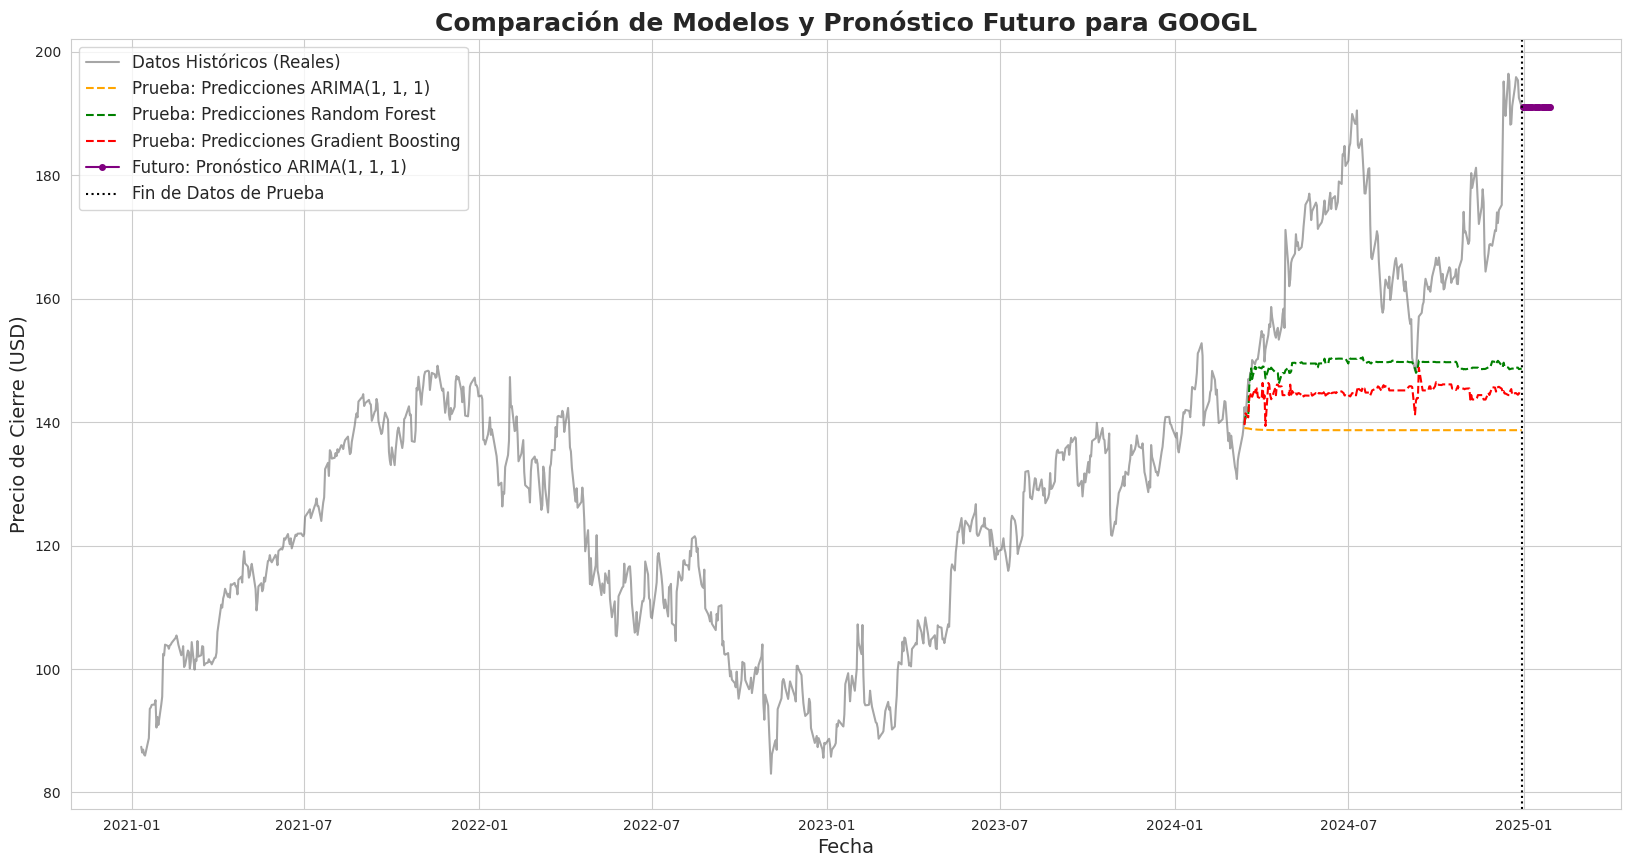

In [6]:
# =============================================================================
# FASE 1: CONFIGURACIÓN DEL ENTORNO
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)
print("Librerías importadas correctamente.")


# =============================================================================
# FASE 2: CARGA Y PREPARACIÓN DE DATOS
# =============================================================================
try:
    df = pd.read_csv('dataset_completo_google_amazon.csv')
except FileNotFoundError:
    print("Error: El archivo 'dataset_completo_google_amazon.csv' no fue encontrado.")
    exit()

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
STOCK_TICKER = 'GOOGL'
TARGET_COLUMN = f'{STOCK_TICKER}_Close'
print(f"Análisis para: {STOCK_TICKER}")


# =============================================================================
# FASE 3: INGENIERÍA DE CARACTERÍSTICAS
# =============================================================================
for i in range(1, 6):
    df[f'{STOCK_TICKER}_Lag_{i}'] = df[TARGET_COLUMN].shift(i)
df_clean = df.dropna()


# =============================================================================
# FASE 4: DIVISIÓN DE DATOS (TRAIN/TEST SPLIT)
# =============================================================================
features = [col for col in df_clean.columns if STOCK_TICKER in col and 'Lag' in col]
features.extend(['Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE'])
X = df_clean[features]
y = df_clean[TARGET_COLUMN]

split_ratio = 0.8
split_index = int(len(X) * split_ratio)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Periodo de entrenamiento: {y_train.index.min().date()} a {y_train.index.max().date()}")
print(f"Periodo de prueba: {y_test.index.min().date()} a {y_test.index.max().date()}")


# =============================================================================
# FASE 5: DEFINICIÓN DE FUNCIONES DE APOYO
# =============================================================================
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mse)

    metrics = {'Modelo': model_name, 'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R^2': r2}
    return metrics

results_list = []


# =============================================================================
# FASE 6.1: MODELO 1 (LÍNEA BASE) - BÚSQUEDA MANUAL DE ARIMA
# =============================================================================
print("\n--- Iniciando Búsqueda Manual de Parámetros para ARIMA ---")

def find_best_arima(data, p_values, d_values, q_values):
    best_score, best_cfg = float("inf"), None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)
                try:
                    model = ARIMA(data, order=order)
                    model_fit = model.fit()
                    if model_fit.aic < best_score:
                        best_score, best_cfg = model_fit.aic, order
                except:
                    continue
    print(f'\nBúsqueda finalizada. Mejor modelo encontrado: ARIMA{best_cfg} con AIC={best_score:.3f}')
    return best_cfg

p_range = range(0, 6); d_range = range(0, 3); q_range = range(0, 6)
best_order = find_best_arima(y_train, p_range, d_range, q_range)

print(f"\n--- Entrenando Modelo ARIMA Final con orden {best_order} ---")
# **NUEVO**: Entrenamos el modelo con el dataset COMPLETO para hacer pronósticos a futuro
# Esto le da al modelo la mayor cantidad de información posible antes de predecir lo desconocido.
full_data_model = ARIMA(y, order=best_order)
full_data_fit = full_data_model.fit()
print("\nResumen del Modelo ARIMA ajustado sobre los datos completos:")
print(full_data_fit.summary())

# Predicciones sobre el conjunto de prueba (para la evaluación comparativa)
# Usamos un modelo entrenado solo con datos de train para una evaluación justa.
train_only_model = ARIMA(y_train, order=best_order).fit()
arima_predictions = train_only_model.forecast(steps=len(y_test))
arima_predictions.index = y_test.index
arima_metrics = evaluate_model(y_test, arima_predictions, 'ARIMA')
results_list.append(arima_metrics)

# **NUEVO**: Pronóstico a futuro para Enero 2025
# Asumimos aproximadamente 22 días hábiles en un mes.
future_steps = 22
future_dates = pd.date_range(start=y.index[-1] + pd.Timedelta(days=1), periods=future_steps, freq='B') # 'B' es para días hábiles
future_forecast = full_data_fit.forecast(steps=future_steps)
future_forecast.index = future_dates

# **NUEVO**: Crear y mostrar la tabla de pronósticos futuros
future_forecast_df = pd.DataFrame({'Fecha': future_dates, f'Pronóstico_{STOCK_TICKER}': future_forecast})
print(f"\n--- Pronósticos Futuros para {STOCK_TICKER} (Enero 2025) ---")
print(future_forecast_df)


# =============================================================================
# FASE 6.2 y 6.3: MODELOS SUPERVISADOS
# =============================================================================
# Random Forest
print("\n--- Entrenando Modelo Random Forest ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_metrics = evaluate_model(y_test, rf_predictions, 'Random Forest')
results_list.append(rf_metrics)

# Gradient Boosting
print("\n--- Entrenando Modelo Gradient Boosting ---")
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)
gb_metrics = evaluate_model(y_test, gb_predictions, 'Gradient Boosting')
results_list.append(gb_metrics)


# =============================================================================
# FASE 7: ANÁLISIS COMPARATIVO Y VISUALIZACIÓN
# =============================================================================
results_df = pd.DataFrame(results_list).set_index('Modelo')
print("\n--- Tabla Comparativa de Resultados Finales ---")
print(results_df.round(4))

predictions_df = pd.DataFrame({
    'Valores Reales': y_test,
    'Predicciones ARIMA': arima_predictions,
    'Predicciones Random Forest': rf_predictions,
    'Predicciones Gradient Boosting': gb_predictions
})

# **NUEVO**: Gráfico mejorado con pronósticos a futuro
plt.figure(figsize=(20, 10))

# Graficar datos históricos
plt.plot(y, label='Datos Históricos (Reales)', color='gray', alpha=0.7)

# Graficar predicciones sobre el conjunto de prueba
plt.plot(predictions_df['Predicciones ARIMA'], label=f'Prueba: Predicciones ARIMA{best_order}', color='orange', linestyle='--')
plt.plot(predictions_df.index, rf_predictions, label='Prueba: Predicciones Random Forest', color='green', linestyle='--')
plt.plot(predictions_df.index, gb_predictions, label='Prueba: Predicciones Gradient Boosting', color='red', linestyle='--')

# **NUEVO**: Graficar el pronóstico a futuro
plt.plot(future_forecast, label=f'Futuro: Pronóstico ARIMA{best_order}', color='purple', linestyle='-', marker='o', markersize=4)

# Línea vertical para separar el período de prueba del futuro
plt.axvline(x=y_test.index[-1], color='black', linestyle=':', label='Fin de Datos de Prueba')

plt.title(f'Comparación de Modelos y Pronóstico Futuro para {STOCK_TICKER}', fontsize=18, fontweight='bold')
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Precio de Cierre (USD)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [7]:
# **NUEVO**: Mostrar la tabla de predicciones del conjunto de prueba
print("\n--- Tabla de Predicciones en el Conjunto de Prueba ---")
# Usamos pd.options para asegurarnos de que se muestren todas las filas
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(predictions_df.round(4))


--- Tabla de Predicciones en el Conjunto de Prueba ---
            Valores Reales  Predicciones ARIMA  Predicciones Random Forest  \
Date                                                                         
2024-03-14        142.4191            139.0636                    139.7565   
2024-03-15        140.5082            139.0110                    140.8736   
2024-03-18        146.9773            138.9657                    141.1881   
2024-03-19        146.3304            138.9267                    145.8264   
2024-03-20        148.0323            138.8933                    147.0284   
2024-03-21        146.8977            138.8644                    148.6961   
2024-03-22        150.0526            138.8397                    146.9749   
2024-03-25        149.3559            138.8183                    148.9456   
2024-03-26        149.9531            138.8000                    148.5751   
2024-03-27        150.1521            138.7843                    149.1512   
2024-03-

Librerías importadas correctamente.
Análisis para: AMZN

Dataset limpio con 992 registros.
Periodo de entrenamiento: 2021-01-11 a 2024-03-13
Periodo de prueba: 2024-03-14 a 2024-12-30

--- Iniciando Búsqueda Manual de Parámetros para ARIMA ---
Evaluando combinaciones (p, d, q)...
  > Mejor configuración encontrada: ARIMA(0, 0, 0) con AIC=7509.553
  > Mejor configuración encontrada: ARIMA(0, 0, 1) con AIC=6545.483
  > Mejor configuración encontrada: ARIMA(0, 0, 2) con AIC=5826.999
  > Mejor configuración encontrada: ARIMA(0, 0, 3) con AIC=5406.304
  > Mejor configuración encontrada: ARIMA(0, 0, 4) con AIC=5078.010
  > Mejor configuración encontrada: ARIMA(0, 0, 5) con AIC=4897.760
  > Mejor configuración encontrada: ARIMA(0, 1, 0) con AIC=4027.977

Búsqueda finalizada. Mejor modelo encontrado: ARIMA(0, 1, 0) con AIC=4027.977

--- Entrenando Modelo ARIMA Final con orden (0, 1, 0) ---

Resumen del Modelo ARIMA ajustado sobre los datos completos:
                               SARIMAX Resu

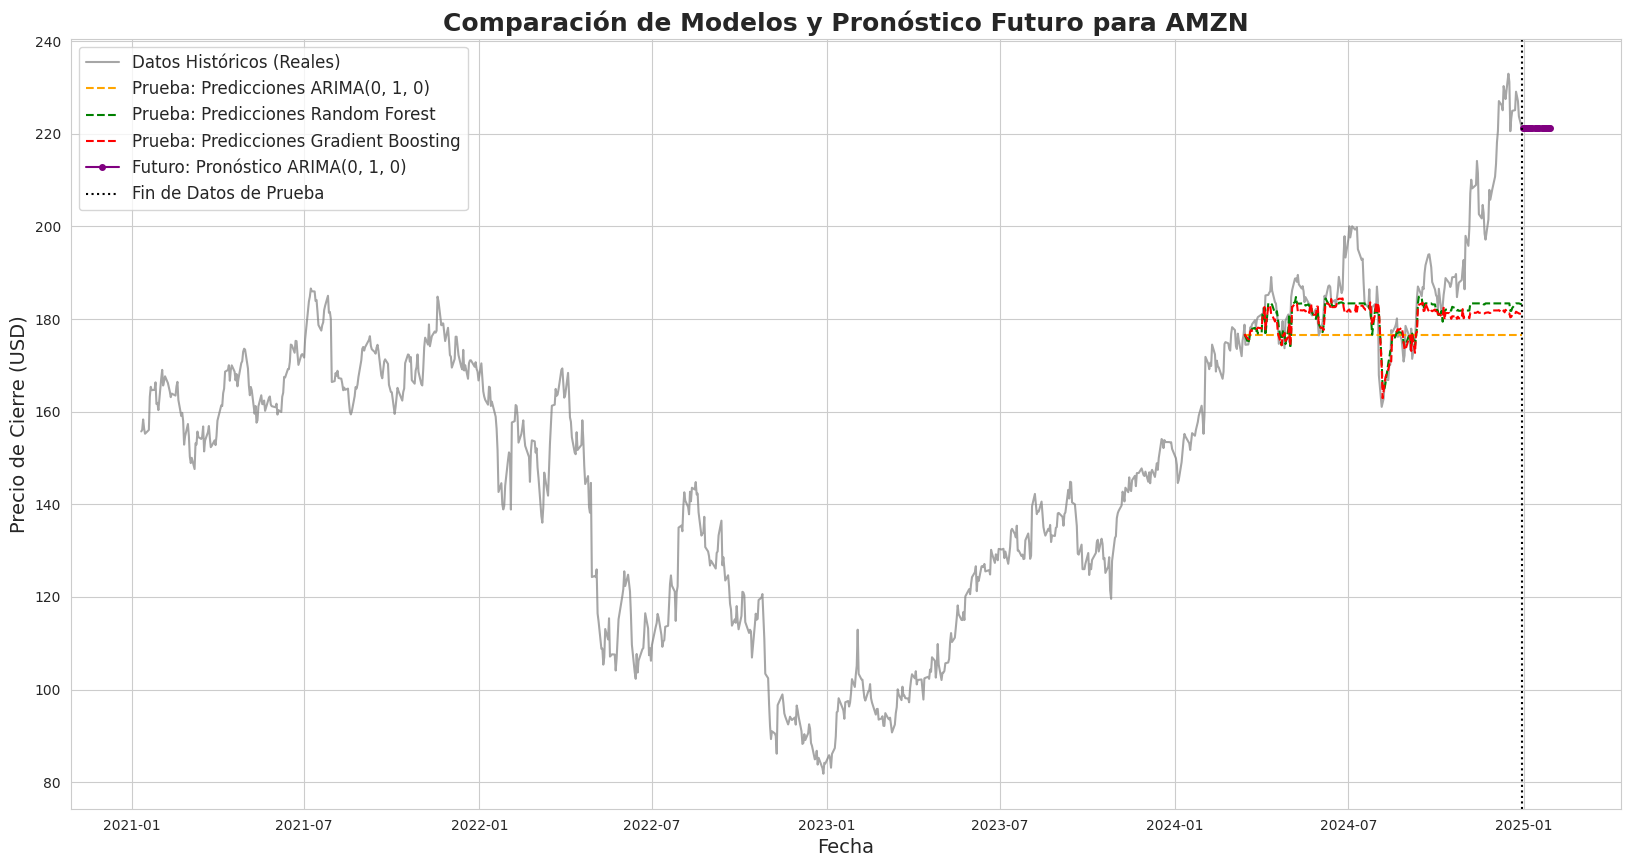

In [8]:
# =============================================================================
# FASE 1: CONFIGURACIÓN DEL ENTORNO para AMAZONE
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)
print("Librerías importadas correctamente.")


# =============================================================================
# FASE 2: CARGA Y PREPARACIÓN DE DATOS
# =============================================================================
try:
    df = pd.read_csv('dataset_completo_google_amazon.csv')
except FileNotFoundError:
    print("Error: El archivo 'dataset_completo_google_amazon.csv' no fue encontrado.")
    exit()

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
# --- MODIFICACIÓN CLAVE PARA AMAZON ---
STOCK_TICKER = 'AMZN'
TARGET_COLUMN = f'{STOCK_TICKER}_Close'
print(f"Análisis para: {STOCK_TICKER}")


# =============================================================================
# FASE 3: INGENIERÍA DE CARACTERÍSTICAS
# =============================================================================
# Crear variables rezagadas (lags)
for i in range(1, 6):
    df[f'{STOCK_TICKER}_Lag_{i}'] = df[TARGET_COLUMN].shift(i)

df_clean = df.dropna()
print(f"\nDataset limpio con {len(df_clean)} registros.")

# =============================================================================
# FASE 4: DIVISIÓN DE DATOS (TRAIN/TEST SPLIT)
# =============================================================================
# Características para modelos supervisados
# Se asegura de tomar solo los lags y columnas relevantes para AMZN
features = [col for col in df_clean.columns if STOCK_TICKER in col and 'Lag' in col]
features.extend(['Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE'])
X = df_clean[features]
y = df_clean[TARGET_COLUMN]

split_ratio = 0.8
split_index = int(len(X) * split_ratio)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Periodo de entrenamiento: {y_train.index.min().date()} a {y_train.index.max().date()}")
print(f"Periodo de prueba: {y_test.index.min().date()} a {y_test.index.max().date()}")


# =============================================================================
# FASE 5: DEFINICIÓN DE FUNCIONES DE APOYO
# =============================================================================
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mse)

    metrics = {'Modelo': model_name, 'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R^2': r2}
    return metrics

results_list = []


# =============================================================================
# FASE 6.1: MODELO 1 (LÍNEA BASE) - BÚSQUEDA MANUAL DE ARIMA
# =============================================================================
print("\n--- Iniciando Búsqueda Manual de Parámetros para ARIMA ---")

def find_best_arima(data, p_values, d_values, q_values):
    best_score, best_cfg = float("inf"), None
    print("Evaluando combinaciones (p, d, q)...")
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)
                try:
                    model = ARIMA(data, order=order)
                    model_fit = model.fit()
                    if model_fit.aic < best_score:
                        best_score, best_cfg = model_fit.aic, order
                        print(f'  > Mejor configuración encontrada: ARIMA{order} con AIC={best_score:.3f}')
                except:
                    continue
    print(f'\nBúsqueda finalizada. Mejor modelo encontrado: ARIMA{best_cfg} con AIC={best_score:.3f}')
    return best_cfg

p_range = range(0, 6); d_range = range(0, 3); q_range = range(0, 6)
best_order = find_best_arima(y_train, p_range, d_range, q_range)

print(f"\n--- Entrenando Modelo ARIMA Final con orden {best_order} ---")
full_data_model = ARIMA(y, order=best_order)
full_data_fit = full_data_model.fit()
print("\nResumen del Modelo ARIMA ajustado sobre los datos completos:")
print(full_data_fit.summary())

train_only_model = ARIMA(y_train, order=best_order).fit()
arima_predictions = train_only_model.forecast(steps=len(y_test))
arima_predictions.index = y_test.index
arima_metrics = evaluate_model(y_test, arima_predictions, 'ARIMA')
results_list.append(arima_metrics)

future_steps = 22
future_dates = pd.date_range(start=y.index[-1] + pd.Timedelta(days=1), periods=future_steps, freq='B')
future_forecast = full_data_fit.forecast(steps=future_steps)
future_forecast.index = future_dates
future_forecast_df = pd.DataFrame({'Fecha': future_dates, f'Pronóstico_{STOCK_TICKER}': future_forecast})


# =============================================================================
# FASE 6.2 y 6.3: MODELOS SUPERVISADOS
# =============================================================================
print("\n--- Entrenando Modelo Random Forest ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_metrics = evaluate_model(y_test, rf_predictions, 'Random Forest')
results_list.append(rf_metrics)

print("\n--- Entrenando Modelo Gradient Boosting ---")
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)
gb_metrics = evaluate_model(y_test, gb_predictions, 'Gradient Boosting')
results_list.append(gb_metrics)


# =============================================================================
# FASE 7: ANÁLISIS COMPARATIVO Y VISUALIZACIÓN
# =============================================================================
results_df = pd.DataFrame(results_list).set_index('Modelo')

predictions_df = pd.DataFrame({
    'Valores Reales': y_test,
    'Predicciones ARIMA': arima_predictions,
    'Predicciones Random Forest': rf_predictions,
    'Predicciones Gradient Boosting': gb_predictions
})

# Mostrar las tablas de resultados
print("\n--- Tabla Comparativa de Métricas de Rendimiento ---")
print(results_df.round(4))

print("\n--- Tabla de Predicciones en el Conjunto de Prueba ---")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(predictions_df.round(4))

print(f"\n--- Pronósticos Futuros para {STOCK_TICKER} (Enero 2025) ---")
print(future_forecast_df.round(4))

# Graficar los resultados
plt.figure(figsize=(20, 10))
plt.plot(y, label='Datos Históricos (Reales)', color='gray', alpha=0.7)
plt.plot(predictions_df['Predicciones ARIMA'], label=f'Prueba: Predicciones ARIMA{best_order}', color='orange', linestyle='--')
plt.plot(predictions_df.index, rf_predictions, label='Prueba: Predicciones Random Forest', color='green', linestyle='--')
plt.plot(predictions_df.index, gb_predictions, label='Prueba: Predicciones Gradient Boosting', color='red', linestyle='--')
plt.plot(future_forecast, label=f'Futuro: Pronóstico ARIMA{best_order}', color='purple', linestyle='-', marker='o', markersize=4)
plt.axvline(x=y_test.index[-1], color='black', linestyle=':', label='Fin de Datos de Prueba')

plt.title(f'Comparación de Modelos y Pronóstico Futuro para {STOCK_TICKER}', fontsize=18, fontweight='bold')
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Precio de Cierre (USD)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

Librerías importadas correctamente.
Análisis para: AMZN

Dataset limpio con 992 registros.
Periodo de entrenamiento: 2021-01-11 a 2024-03-13
Periodo de prueba: 2024-03-14 a 2024-12-30

--- Modelo ARIMA ---
--- Modelo Random Forest ---
--- Modelo Gradient Boosting ---

--- Generando Pronósticos Futuros (Ene-Feb 2025) ---

--- Tabla Comparativa de Métricas de Rendimiento ---
                        MSE      MAE     RMSE     R^2
Modelo                                               
ARIMA              388.9152  14.1486  19.7209 -0.7324
Random Forest      245.4807   9.5671  15.6678 -0.0935
Gradient Boosting  274.0456  10.2762  16.5543 -0.2207

--- Tabla de Predicciones en el Conjunto de Prueba ---
            Valores Reales  Predicciones ARIMA  Predicciones Random Forest  \
Date                                                                         
2024-03-14          178.75              176.56                    176.6537   
2024-03-15          174.42              176.56                  

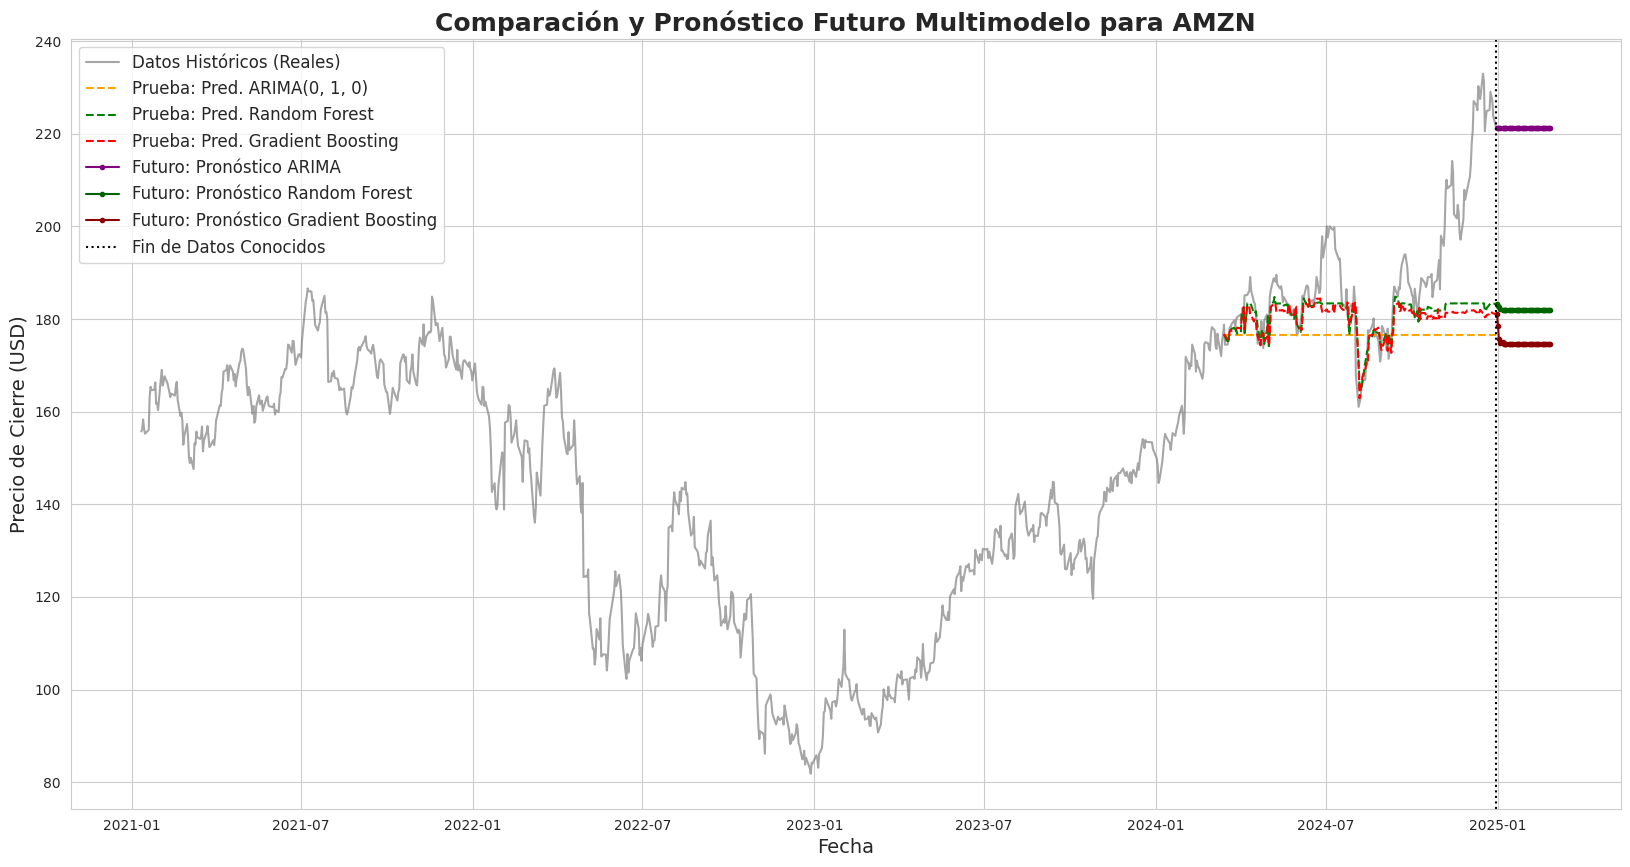

In [9]:
# =============================================================================
# FASE 1: CONFIGURACIÓN DEL ENTORNO
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)
print("Librerías importadas correctamente.")


# =============================================================================
# FASE 2: CARGA Y PREPARACIÓN DE DATOS
# =============================================================================
try:
    df = pd.read_csv('dataset_completo_google_amazon.csv')
except FileNotFoundError:
    print("Error: El archivo 'dataset_completo_google_amazon.csv' no fue encontrado.")
    exit()

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
STOCK_TICKER = 'AMZN'
TARGET_COLUMN = f'{STOCK_TICKER}_Close'
print(f"Análisis para: {STOCK_TICKER}")


# =============================================================================
# FASE 3: INGENIERÍA DE CARACTERÍSTICAS
# =============================================================================
for i in range(1, 6):
    df[f'{STOCK_TICKER}_Lag_{i}'] = df[TARGET_COLUMN].shift(i)
df_clean = df.dropna()
print(f"\nDataset limpio con {len(df_clean)} registros.")

# =============================================================================
# FASE 4: DIVISIÓN DE DATOS (TRAIN/TEST SPLIT)
# =============================================================================
features = [col for col in df_clean.columns if STOCK_TICKER in col and 'Lag' in col]
features.extend(['Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE'])
X = df_clean[features]
y = df_clean[TARGET_COLUMN]

split_ratio = 0.8; split_index = int(len(X) * split_ratio)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Periodo de entrenamiento: {y_train.index.min().date()} a {y_train.index.max().date()}")
print(f"Periodo de prueba: {y_test.index.min().date()} a {y_test.index.max().date()}")


# =============================================================================
# FASE 5: DEFINICIÓN DE FUNCIONES DE APOYO
# =============================================================================
def evaluate_model(y_true, y_pred, model_name):
    # ... (función sin cambios)
    mse = mean_squared_error(y_true, y_pred); mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred); rmse = np.sqrt(mse)
    return {'Modelo': model_name, 'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R^2': r2}

results_list = []


# =============================================================================
# FASE 6: MODELADO, EVALUACIÓN Y PRONÓSTICO
# =============================================================================
# --- MODELO ARIMA ---
print("\n--- Modelo ARIMA ---")
best_order = (0, 1, 0) # Orden encontrado para AMZN
# Modelo para evaluación (entrenado solo en train)
train_arima_model = ARIMA(y_train, order=best_order).fit()
arima_predictions_test = train_arima_model.forecast(steps=len(y_test))
arima_predictions_test.index = y_test.index
results_list.append(evaluate_model(y_test, arima_predictions_test, 'ARIMA'))
# Modelo para pronóstico futuro (entrenado en todos los datos)
full_arima_model = ARIMA(y, order=best_order).fit()

# --- MODELO RANDOM FOREST ---
print("--- Modelo Random Forest ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_predictions_test = rf_model.predict(X_test)
results_list.append(evaluate_model(y_test, rf_predictions_test, 'Random Forest'))

# --- MODELO GRADIENT BOOSTING ---
print("--- Modelo Gradient Boosting ---")
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
gb_predictions_test = gb_model.predict(X_test)
results_list.append(evaluate_model(y_test, gb_predictions_test, 'Gradient Boosting'))

# =============================================================================
# **NUEVO**: FASE DE PRONÓSTICO FUTURO RECURSIVO
# =============================================================================
print("\n--- Generando Pronósticos Futuros (Ene-Feb 2025) ---")
# Definir el horizonte de pronóstico (aprox. 42 días hábiles para 2 meses)
future_steps = 42
last_date = y.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps, freq='B')

# --- Pronóstico ARIMA ---
arima_forecast_future = full_arima_model.forecast(steps=future_steps)
arima_forecast_future.index = future_dates

# --- Pronóstico Recursivo para Modelos Supervisados ---
def recursive_forecast(model, X_last, n_steps):
    """Genera un pronóstico recursivo para modelos supervisados."""
    last_features = X_last.copy()
    forecast = []

    for _ in range(n_steps):
        # Predecir el siguiente paso
        next_pred = model.predict(last_features)[0]
        forecast.append(next_pred)

        # Actualizar las características para el siguiente paso
        # Crear un nuevo registro de características, desplazando los lags
        new_features = last_features.copy()
        for i in range(4, 0, -1):
            new_features[0, i] = new_features[0, i-1] # Desplazar lags
        new_features[0, 0] = next_pred # El nuevo lag 1 es la predicción

        last_features = new_features

    return np.array(forecast)

# Preparar las últimas características conocidas
last_known_X = X.iloc[-1:].values

# Generar pronósticos
rf_forecast_future = recursive_forecast(rf_model, last_known_X, future_steps)
gb_forecast_future = recursive_forecast(gb_model, last_known_X, future_steps)


# =============================================================================
# FASE 7: ANÁLISIS COMPARATIVO Y VISUALIZACIÓN
# =============================================================================
results_df = pd.DataFrame(results_list).set_index('Modelo')
predictions_df = pd.DataFrame({
    'Valores Reales': y_test,
    'Predicciones ARIMA': arima_predictions_test,
    'Predicciones Random Forest': rf_predictions_test,
    'Predicciones Gradient Boosting': gb_predictions_test
})
future_forecast_df = pd.DataFrame({
    'Fecha': future_dates,
    f'Pronóstico_ARIMA': arima_forecast_future,
    f'Pronóstico_Random_Forest': rf_forecast_future,
    f'Pronóstico_Gradient_Boosting': gb_forecast_future
})

print("\n--- Tabla Comparativa de Métricas de Rendimiento ---")
print(results_df.round(4))
print("\n--- Tabla de Predicciones en el Conjunto de Prueba ---")
with pd.option_context('display.max_rows', 10): print(predictions_df.round(4))
print(f"\n--- Pronósticos Futuros para {STOCK_TICKER} (Ene-Feb 2025) ---")
with pd.option_context('display.max_rows', 10): print(future_forecast_df.round(4))

# Graficar los resultados
plt.figure(figsize=(20, 10))
plt.plot(y, label='Datos Históricos (Reales)', color='gray', alpha=0.7)
plt.plot(predictions_df['Predicciones ARIMA'], label=f'Prueba: Pred. ARIMA{best_order}', color='orange', linestyle='--')
plt.plot(predictions_df.index, rf_predictions_test, label='Prueba: Pred. Random Forest', color='green', linestyle='--')
plt.plot(predictions_df.index, gb_predictions_test, label='Prueba: Pred. Gradient Boosting', color='red', linestyle='--')

# Graficar pronósticos a futuro
plt.plot(future_forecast_df['Fecha'], future_forecast_df['Pronóstico_ARIMA'], label='Futuro: Pronóstico ARIMA', color='purple', linestyle='-', marker='.')
plt.plot(future_forecast_df['Fecha'], future_forecast_df['Pronóstico_Random_Forest'], label='Futuro: Pronóstico Random Forest', color='darkgreen', linestyle='-', marker='.')
plt.plot(future_forecast_df['Fecha'], future_forecast_df['Pronóstico_Gradient_Boosting'], label='Futuro: Pronóstico Gradient Boosting', color='darkred', linestyle='-', marker='.')

plt.axvline(x=y.index[-1], color='black', linestyle=':', label='Fin de Datos Conocidos')
plt.title(f'Comparación y Pronóstico Futuro Multimodelo para {STOCK_TICKER}', fontsize=18, fontweight='bold')
plt.xlabel('Fecha', fontsize=14); plt.ylabel('Precio de Cierre (USD)', fontsize=14)
plt.legend(fontsize=12); plt.grid(True)
plt.show()

## Fase 3: Implementación de Modelos Tradicionales (ARIMA y GARCH)

Se implementarán modelos ARIMA para la predicción de precios y se explorará la aplicación de GARCH para la volatilidad, con una simplificación para la predicción de precios para fines comparativos. Se utilizarán las métricas MSE y R2 para evaluar su rendimiento.

In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 14.6 MB/s eta 0:00:00


## MODELO ARIMA VS ARIMAX

Librerías importadas correctamente.
Análisis para: GOOGL

--- Modelo ARIMA (Línea Base) ---
Test de Estacionariedad (ADF) p-value: 0.2065. Orden de diferenciación 'd' establecido en: 1
Mejor orden para ARIMA univariado: (1, 1, 1) con AIC: 3585.02

--- Modelo ARIMAX ---
Mejor orden para ARIMAX: (0, 1, 0) con AIC: 2888.13

Resumen del Modelo ARIMAX ajustado:
                               SARIMAX Results                                
Dep. Variable:            GOOGL_Close   No. Observations:                  793
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -1438.067
Date:                Sat, 28 Jun 2025   AIC                           2888.133
Time:                        18:28:21   BIC                           2916.180
Sample:                             0   HQIC                          2898.913
                                - 793                                         
Covariance Type:                  opg                                         
         

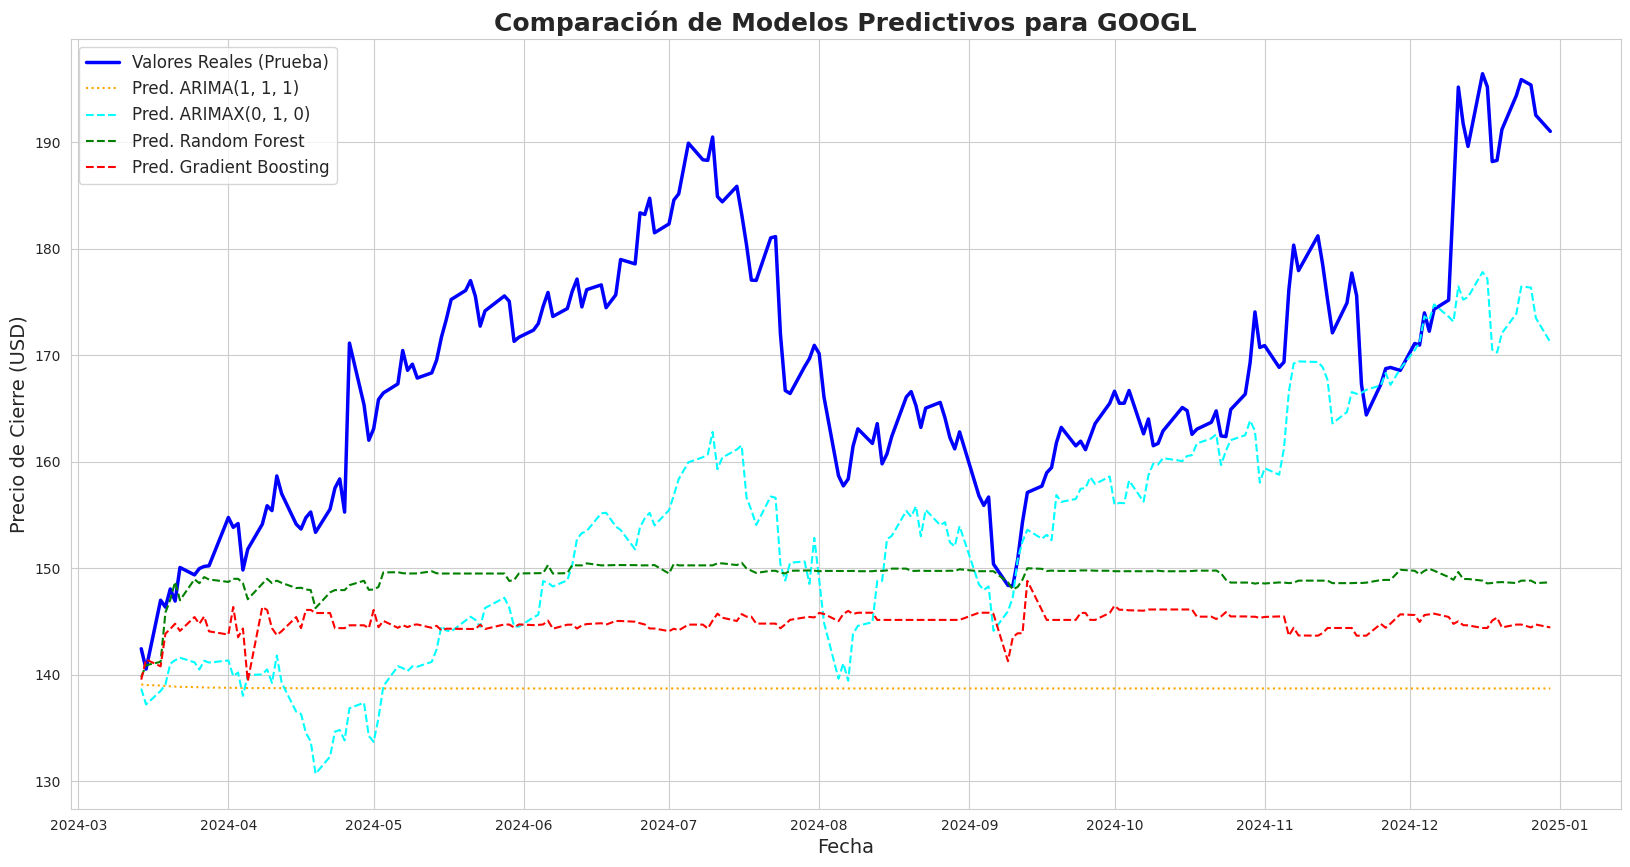

In [10]:
# =============================================================================
# FASE 1: CONFIGURACIÓN DEL ENTORNO
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller # Para test de estacionariedad
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)
print("Librerías importadas correctamente.")

# =============================================================================
# FASE 2: CARGA Y PREPARACIÓN DE DATOS
# =============================================================================
try:
    df = pd.read_csv('dataset_completo_google_amazon.csv')
except FileNotFoundError:
    print("Error: El archivo 'dataset_completo_google_amazon.csv' no fue encontrado.")
    exit()

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
STOCK_TICKER = 'GOOGL' # Cambiar a 'AMZN' para el otro análisis
TARGET_COLUMN = f'{STOCK_TICKER}_Close'
print(f"Análisis para: {STOCK_TICKER}")

# =============================================================================
# FASE 3: INGENIERÍA DE CARACTERÍSTICAS
# =============================================================================
for i in range(1, 6):
    df[f'{STOCK_TICKER}_Lag_{i}'] = df[TARGET_COLUMN].shift(i)
df_clean = df.dropna()

# =============================================================================
# FASE 4: DIVISIÓN DE DATOS (TRAIN/TEST SPLIT)
# =============================================================================
# Características para modelos supervisados Y ARIMAX
exog_features = ['Treasury_10Y', 'VIX', 'SP500', 'NASDAQ', 'Inflacion_T5YIE']
ml_features = [col for col in df_clean.columns if STOCK_TICKER in col and 'Lag' in col] + exog_features

X = df_clean[ml_features]
y = df_clean[TARGET_COLUMN]
X_exog = df_clean[exog_features] # Variables exógenas para ARIMAX

split_ratio = 0.8
split_index = int(len(X) * split_ratio)

# División para modelos de ML
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
# División para ARIMA/ARIMAX
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
exog_train, exog_test = X_exog.iloc[:split_index], X_exog.iloc[split_index:]

# =============================================================================
# FASE 5: DEFINICIÓN DE FUNCIONES DE APOYO
# =============================================================================
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred); mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred); rmse = np.sqrt(mse)
    return {'Modelo': model_name, 'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R^2': r2}

results_list = []

# =============================================================================
# FASE 6: MODELADO Y EVALUACIÓN
# =============================================================================

# --- MODELO 1: ARIMA (Univariado) ---
print("\n--- Modelo ARIMA (Línea Base) ---")
# Determinar el orden de diferenciación 'd'
adf_result = adfuller(y_train)
d = 1 if adf_result[1] > 0.05 else 0
print(f"Test de Estacionariedad (ADF) p-value: {adf_result[1]:.4f}. Orden de diferenciación 'd' establecido en: {d}")

# Búsqueda manual de p y q para ARIMA
best_aic_arima, best_order_arima = float("inf"), None
p_range = range(0, 4); q_range = range(0, 4)
for p in p_range:
    for q in q_range:
        try:
            model = ARIMA(y_train, order=(p, d, q)).fit()
            if model.aic < best_aic_arima:
                best_aic_arima, best_order_arima = model.aic, (p, d, q)
        except: continue
print(f"Mejor orden para ARIMA univariado: {best_order_arima} con AIC: {best_aic_arima:.2f}")
arima_model = ARIMA(y_train, order=best_order_arima).fit()
arima_predictions = arima_model.forecast(steps=len(y_test))
results_list.append(evaluate_model(y_test, arima_predictions, 'ARIMA'))

# --- MODELO 2: ARIMAX (con Variables Exógenas) ---
print("\n--- Modelo ARIMAX ---")
best_aic_arimax, best_order_arimax = float("inf"), None
for p in p_range:
    for q in q_range:
        try:
            model = ARIMA(y_train, exog=exog_train, order=(p, d, q)).fit()
            if model.aic < best_aic_arimax:
                best_aic_arimax, best_order_arimax = model.aic, (p, d, q)
        except: continue
print(f"Mejor orden para ARIMAX: {best_order_arimax} con AIC: {best_aic_arimax:.2f}")
arimax_model = ARIMA(y_train, exog=exog_train, order=best_order_arimax).fit()
arimax_predictions = arimax_model.forecast(steps=len(y_test), exog=exog_test)
results_list.append(evaluate_model(y_test, arimax_predictions, 'ARIMAX'))
print("\nResumen del Modelo ARIMAX ajustado:")
print(arimax_model.summary())

# --- MODELO 3: Random Forest ---
print("\n--- Modelo Random Forest ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
results_list.append(evaluate_model(y_test, rf_predictions, 'Random Forest'))

# --- MODELO 4: Gradient Boosting ---
print("\n--- Modelo Gradient Boosting ---")
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42).fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)
results_list.append(evaluate_model(y_test, gb_predictions, 'Gradient Boosting'))

# =============================================================================
# FASE 7: ANÁLISIS COMPARATIVO
# =============================================================================
results_df = pd.DataFrame(results_list).set_index('Modelo')
print("\n--- Tabla Comparativa de Métricas de Rendimiento ---")
print(results_df.round(4))

# Graficar los resultados
plt.figure(figsize=(20, 10))
plt.plot(y_test.index, y_test, label='Valores Reales (Prueba)', color='blue', linewidth=2.5)
plt.plot(y_test.index, arima_predictions, label=f'Pred. ARIMA{best_order_arima}', color='orange', linestyle=':')
plt.plot(y_test.index, arimax_predictions, label=f'Pred. ARIMAX{best_order_arimax}', color='cyan', linestyle='--')
plt.plot(y_test.index, rf_predictions, label='Pred. Random Forest', color='green', linestyle='--')
plt.plot(y_test.index, gb_predictions, label='Pred. Gradient Boosting', color='red', linestyle='--')

plt.title(f'Comparación de Modelos Predictivos para {STOCK_TICKER}', fontsize=18, fontweight='bold')
plt.xlabel('Fecha', fontsize=14); plt.ylabel('Precio de Cierre (USD)', fontsize=14)
plt.legend(fontsize=12); plt.grid(True)
plt.show()

Se consolidarán los resultados de todos los modelos y se generarán tablas y gráficos comparativos para visualizar sus rendimientos relativos.

## Fase 6: Interpretaciones Financieras y Estadísticas Detalladas